<center>
    <img src="https://rockborne.com/wp-content/uploads/2021/07/LandingPage-Header-RED-CENTRE.jpg" width="900" alt="logo"  />
</center>

# Practical Pandas: Working with a Real Database (Student Version)

## About this notebook
This practical lets you put into practice everything from the **Pandas Walkthrough**, this time on a real, multi-table database rather than a single tidy file. You will move through short, focused exercises that gradually build on one another: exploring data, selecting and sorting, filtering, creating columns, aggregating with `groupby`, and joining tables together. The final exercises pull all of these skills into a couple of genuine business questions.

## About the exercises
Each exercise is made of two cells:

1. **The question** (a markdown cell like this one).
2. **`# Your turn`**: an empty code cell for you to write your solution.

Have a go at each one yourself. Later exercises reuse variables created in earlier ones, so work through them in order.

## About the database: Pagila
We use **Pagila**, a well-known sample database for a fictional DVD-rental company. Its CSV files live one folder up from this notebook, in [`../datasets/pagila_csv/`](../datasets/pagila_csv/). Pagila spreads its data across many tables (customers, addresses, payments, films, actors, categories, inventory and more). A core skill you will practise is reading the **Entity-Relationship (ER) diagram** below to work out *which* tables you need and *how* they connect.

## Reference: the Pagila ER diagram
Keep this diagram handy. Several exercises ask you to decide which tables to join based on it.

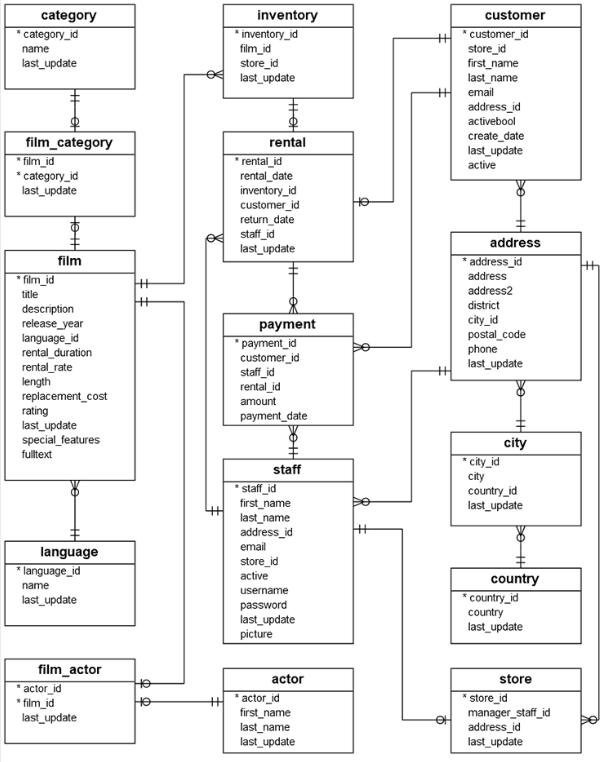

---
# Part 0: Setup and loading the data

First we import the libraries we need. Because the data sits **one directory above** this notebook, every path starts with `../` (go up one level), followed by `datasets/pagila_csv/`.

In [ ]:
import pandas as pd
import glob

In [ ]:
customer = (
    spark.read.csv(
        pagila_datasets["customer"],
        header=True,
        inferSchema=True
    )
).toPandas()

address = (
    spark.read.csv(
        pagila_datasets["address"],
        header=True,
        inferSchema=True
    )
).toPandas()

city = (
    spark.read.csv(
        pagila_datasets["city"],
        header=True,
        inferSchema=True
    )
).toPandas()

country = (
    spark.read.csv(
        pagila_datasets["country"],
        header=True,
        inferSchema=True
    )
).toPandas()

In [ ]:
##From S3
# Load a few dimension tables we'll reuse throughout


### Exercise 0: Build the sales table by union

The sales (payment) data is **split across 7 monthly files** (`payment_p2022_01.csv` ... `payment_p2022_07.csv`). Stack them on top of each other (a *union* of rows) into a single DataFrame called `payment`, then check its shape.

> *Hint: `glob.glob()` finds files matching a pattern; `pd.concat([...])` unions a list of DataFrames. Use `ignore_index=True` so the row index is renumbered cleanly.*

In [ ]:
# Your turn. Write your solution here:


---
# Part 1: Explore the data
Before analysing anything, get a feel for what each table contains.

### Exercise 1.1: First look at the payments

Show the first few rows of `payment`, then list its column names.

In [ ]:
# Your turn. Write your solution here:


### Exercise 1.2: Column types

What **data type** is each column in `payment`? In particular, is `payment_date` stored as a date or as text? Is `amount` numeric?

> *Hint: `.info()` shows the dtype of every column at once.*

In [ ]:
# Your turn. Write your solution here:


### Exercise 1.3: Summary statistics

Use a single method to get the count, mean, min and max of the numeric columns in `payment`. What is the largest single payment?

> *Hint: `.describe()` summarises the numeric columns.*

In [ ]:
# Your turn. Write your solution here:


---
# Part 2: Selecting columns and sorting


### Exercise 2.1: Select two columns

Create a DataFrame with only the `customer_id` and `amount` columns from `payment`.

> *Hint: Selecting multiple columns needs a *list* of names inside the square brackets.*

In [ ]:
# Your turn. Write your solution here:


### Exercise 2.2: Find the biggest payments

Sort `payment` by `amount` from highest to lowest and show the top 5 rows.

> *Hint: `sort_values(by=..., ascending=False)` sorts high to low.*

In [ ]:
# Your turn. Write your solution here:


### Exercise 2.3: Sort customers alphabetically

Show customers sorted by `last_name` (A to Z).

In [ ]:
# Your turn. Write your solution here:


---
# Part 3: Filtering rows


### Exercise 3.1: High-value payments

Select only the payments where `amount` is greater than 8.

> *Hint: Put a boolean condition inside the square brackets.*

In [ ]:
# Your turn. Write your solution here:


### Exercise 3.2: Customers of a single store

Select the customers belonging to store 2.

In [ ]:
# Your turn. Write your solution here:


### Exercise 3.3: Combine two conditions

Select customers who belong to store 2 **and** are active (`active == 1`).

> *Hint: Combine conditions with `&` and wrap each one in parentheses.*

In [ ]:
# Your turn. Write your solution here:


### Exercise 3.4: Filter by a list of values

Select the payments made by customers with id 1, 2 or 3.

> *Hint: `.isin([...])` tests membership against a list, much tidier than chaining `|`.*

In [ ]:
# Your turn. Write your solution here:


---
# Part 4: Creating columns


### Exercise 4.1: A full-name column

Add a new column `full_name` to `customer` that joins `first_name` and `last_name` with a space, for example `MARY SMITH`.

In [ ]:
# Your turn. Write your solution here:


### Exercise 4.2: Bucket payments with `.apply()`

Write a function that labels an amount as `'small'` (below 3), `'medium'` (3 to 7) or `'large'` (above 7), then use `.apply()` to create a `size` column on `payment`.

> *Hint: Define a normal Python function, then call `payment['amount'].apply(your_function)`.*

In [ ]:
# Your turn. Write your solution here:


---
# Part 5: Aggregating with `groupby`
This is the key skill for the analysis at the end of the notebook.

### Exercise 5.1: Total spent per customer

Group `payment` by `customer_id` and find the **total** amount each customer has spent.

In [ ]:
# Your turn. Write your solution here:


### Exercise 5.2: Total sales per month

You combined all of the monthly sales into `payment` back in Exercise 0. Now that every month sits in one table, find the **total revenue** and the **number of payments** for each calendar month.

> *Hint: Convert `payment_date` with `pd.to_datetime(..., utc=True)`, pull out the month with `.dt.month`, then `groupby('month')` and aggregate.*

In [ ]:
# Your turn. Write your solution here:


### Exercise 5.3: Sales handled per staff member

Each payment records the `staff_id` who processed it. How much total revenue has each staff member handled, and how many payments did they process?

> *Hint: `groupby(...).agg(new_name=(column, function))` lets you compute several aggregates at once.*

In [ ]:
# Your turn. Write your solution here:


### Exercise 5.4: Multiple statistics at once

For each `customer_id`, compute the **sum**, **mean** and **max** of `amount` in a single call.

In [ ]:
# Your turn. Write your solution here:


---
# Part 6: Joining two tables
Real questions usually span several tables. Practise a single join first.

### Exercise 6.1: Attach each customer's address

`customer` has an `address_id`; the street details live in `address`. Merge the two so each customer row also shows its `address` and `district`. Use a **left** join keyed on `address_id`.

> *Hint: `pd.merge(left=, right=, on='address_id', how='left')`.*

In [ ]:
# Your turn. Write your solution here:


---
# Part 7: Use the ER diagram (the film catalogue)
These questions use tables we have **not** loaded yet (`film`, `category`, `film_category`, `film_actor`, `actor`). Look back at the ER diagram, decide which tables you need and how they join, then load them from `DATA` and answer. The first answer shows the loading pattern.

### Exercise 7.1: Which film categories have the most films?

A film's genre is stored in `category`, but the link between films and categories is in `film_category`. Count how many films fall in each category and show the top 5.

> *Hint: `film_category` joins `film_id` to `category_id`; `category` turns the id into a name. `groupby(...).size()` counts rows per group.*

In [ ]:
# Your turn. Write your solution here:


### Exercise 7.2: Which actor appears in the most films?

`film_actor` links actors to films. Count the films per actor, attach the actor's name from `actor`, then show the busiest actor.

In [ ]:
# Your turn. Write your solution here:


### Exercise 7.3: How many films per age rating?

The `film` table has a `rating` column (G, PG, PG-13, R, NC-17). Count the films in each rating.

> *Hint: Everything you need is in a single table, so no join is required.*

In [ ]:
# Your turn. Write your solution here:


### Exercise 7.4: Average rental rate per category

Combining what you've done above: what is the **average `rental_rate`** for each film category? Show the 5 most expensive categories.

> *Hint: You need `film_category` (the link), `film` (for `rental_rate`) and `category` (for the name).*

In [ ]:
# Your turn. Write your solution here:


---
# Part 8: Which EU countries generate the most sales?

Now bring everything together. A customer's country is several joins away from their payments:

`payment` ▸ `customer` ▸ `address` ▸ `city` ▸ `country`

We'll build it step by step, exactly as you practised above.

### Exercise 8.1: Total spent by each customer

Create a DataFrame `customer_payments` holding the total `amount` spent by each `customer_id`.

In [ ]:
# Your turn. Write your solution here:


### Exercise 8.2: Rename the column

Rename the `amount` column of `customer_payments` to `total_amount`.

In [ ]:
# Your turn. Write your solution here:


### Exercise 8.3: Add the customer details

Merge `customer_payments` with `customer` (left join on `customer_id`). Call the result `customer_payments_details`.

In [ ]:
# Your turn. Write your solution here:


The `customer`, `address`, `city` and `country` tables all carry a `last_update` column. Drop it now to avoid clashing column names when we merge.

In [ ]:
customer_payments_details.drop(columns='last_update', inplace=True)

### Exercise 8.4: Join city to country

Merge `city` with `country` (left join on `country_id`). Call it `cities_and_country`.

In [ ]:
# Your turn. Write your solution here:


### Exercise 8.5: Join that to address

Merge `address` with `cities_and_country` (left join on `city_id`). Call it `address_city_and_country`.

In [ ]:
# Your turn. Write your solution here:


### Exercise 8.6: Bring customers and locations together

Merge `customer_payments_details` with `address_city_and_country` (left join on `address_id`). Call it `customer_payment_full_details`.

In [ ]:
# Your turn. Write your solution here:


### Exercise 8.7: Keep only what we need

From `customer_payment_full_details`, keep just `customer_id`, `total_amount` and `country`. Call it `customer_payment_details`.

In [ ]:
# Your turn. Write your solution here:


### Exercise 8.8: Total sales per country

Group `customer_payment_details` by `country` and sum `total_amount`. Sort ascending and reset the index. Call it `sales_per_country`.

In [ ]:
# Your turn. Write your solution here:


Let's look at the distribution of sales across **all** countries.

In [ ]:
sales_per_country.plot.barh(x='country', y='total_amount', figsize=(8, 20));

We're given the list of EU countries to filter with. Run this cell first:

In [ ]:
eu_countries = ['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Czech Republic', 'Denmark', 'Estonia',
                'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia',
                'Lithuania', 'Luxembourg', 'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania',
                'Slovakia', 'Slovenia', 'Spain', 'Sweden']

### Exercise 8.9: Filter to the EU

We only care about EU countries. Use the provided `eu_countries` list to keep only EU rows. Call the result `sales_per_eu_country`.

> *Hint: `.isin(eu_countries)` is the same trick from Exercise 3.4.*

In [ ]:
# Your turn. Write your solution here:


And the bar plot for EU countries only, **the answer to our first question**.

In [ ]:
sales_per_eu_country.plot.barh(x='country', y='total_amount');

### Exercise 8.10: Export the result

Save `sales_per_eu_country` to a CSV called `eu_sales.csv` in the datasets folder.

In [ ]:
# Your turn. Write your solution here:


---
# Part 9: Who are the top-spending EU customers?
We now know which *countries* sell most. Let's drill down to *individual customers*.

### Exercise 9: Top 10 EU customers by spend

Starting from `customer_payment_full_details`, keep only customers in `eu_countries`, then show the **top 10 customers** by `total_amount`, including their name and country.

> *Hint: Filter with `.isin(eu_countries)`, then `sort_values(..., ascending=False).head(10)`.*

In [ ]:
# Your turn. Write your solution here:


<a name="anchorReading" style="position:absolute;"></a>
<hr style="border:2px solid">

# 13. Further Reading
<hr style="border-top:1px dashed">

### Tutorials
- [Automate the Boring Stuff with Python](https://automatetheboringstuff.com/) is an online (and paper!) book with basic Python tutorials and inspiration on what to do with Python.
- [Towards Data Science](https://towardsdatascience.com/) has articles about data science and data science tools, many of which rely on Python.
- [stack**overflow**](https://stackoverflow.com/questions/tagged/python) is a question and answer site for programming questions.
- [scipy lectures](http://scipy-lectures.org/) are a tutorial for using Python in Scientific computing, including data analysis

### Pandas information
- [Pandas cheatsheet](https://github.com/pandas-dev/pandas/blob/master/doc/cheatsheet/Pandas_Cheat_Sheet.pdf)
- [Pandas comparison with SQL](https://pandas.pydata.org/pandas-docs/stable/getting_started/comparison/comparison_with_sql.html)
- On Aptem, in the ***Python Videos*** component of the Learning plan overview, there is the ***Corndel Pandas Methods.zip***
